In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.feature_selection import r_regression
from sklearn.model_selection import train_test_split

from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

seed = 40
np.random.seed(seed)


## 1. Load the data

In [2]:

df_raw = pd.read_csv('data/NYCU_Iris.csv')
print("Shape:", df_raw.shape)
display(df_raw.head())
print("\nMissing values by column:")
print(df_raw.isna().sum())


Shape: (500, 72)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor



Missing values by column:
Id                        0
SepalLengthCm            28
SepalWidthCm             57
PetalLengthCm           150
PetalWidthCm             22
                       ... 
ThermalResponseIndex      0
UVExposureIndex           0
WindStressIndex           0
GrowthVigorIndex          0
Species                   0
Length: 72, dtype: int64


## 2. Task 3 — Data Preprocessing

Report the median and standard deviation for columns with missing values, then impute missing values using **Nearest Neighbors Imputation** (`KNNImputer`).

In [3]:

def summarize_missing_columns(df):
    numeric_df = df.copy()
    for col in numeric_df.columns:
        if col not in ['Species']:
            numeric_df[col] = pd.to_numeric(numeric_df[col], errors='coerce')
    missing_cols = [c for c in numeric_df.columns if numeric_df[c].isna().sum() > 0]
    summary = pd.DataFrame({
        'missing_count': [numeric_df[c].isna().sum() for c in missing_cols],
        'median_before': [numeric_df[c].median(skipna=True) for c in missing_cols],
        'std_before': [numeric_df[c].std(skipna=True) for c in missing_cols],
    }, index=missing_cols)
    return summary

before_summary = summarize_missing_columns(df_raw)
print("Columns with missing values (before imputation):")
display(before_summary)


Columns with missing values (before imputation):


,missing_count,median_before,std_before
SepalLengthCm,28,6.300000,1.037115
SepalWidthCm,57,2.900000,0.389564
PetalLengthCm,150,5.085612,1.582807
PetalWidthCm,22,1.600000,0.706689
BranchLength,24,16.300000,1.035228


In [4]:

def data_preprocessing(df):
    df = df.copy()

    # Transform label to binary class for logistic regression
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    encoded_species = le.fit_transform(df['Species'])

    # Binary transformation:
    # smallest encoded class -> 0, all other classes -> 1
    # This keeps the task compatible with binary logistic regression.
    df['Species'] = (encoded_species != encoded_species.min()).astype(int)

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # Convert feature columns to numeric
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Nearest Neighbors Imputation
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])

    return df, feature_cols, le

df, feature_cols, label_encoder = data_preprocessing(df_raw)
print("Preprocessed shape:", df.shape)
display(df.head())
print("\nMissing values after preprocessing:")
print(df[feature_cols].isna().sum())


Preprocessed shape: (500, 72)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,3.02,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,0
1,2,6.4,3.20,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,0
2,3,6.9,3.04,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,0
3,4,5.5,2.30,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,0
4,5,6.5,2.80,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,0



Missing values after preprocessing:
SepalLengthCm            0
SepalWidthCm             0
PetalLengthCm            0
PetalWidthCm             0
BranchLength             0
                        ..
AmbientHumiditySignal    0
ThermalResponseIndex     0
UVExposureIndex          0
WindStressIndex          0
GrowthVigorIndex         0
Length: 70, dtype: int64


In [5]:

after_summary = pd.DataFrame({
    'median_after': [df[col].median() for col in before_summary.index],
    'std_after': [df[col].std() for col in before_summary.index],
}, index=before_summary.index)

comparison_summary = before_summary.join(after_summary)
comparison_summary['median_change'] = comparison_summary['median_after'] - comparison_summary['median_before']
comparison_summary['std_change'] = comparison_summary['std_after'] - comparison_summary['std_before']

print("Comparison of missing-value columns before vs after KNN imputation:")
display(comparison_summary)


Comparison of missing-value columns before vs after KNN imputation:


,missing_count,median_before,std_before,median_after,std_after,median_change,std_change
SepalLengthCm,28,6.300000,1.037115,6.300000,1.009275,0.000000,-0.027840
SepalWidthCm,57,2.900000,0.389564,2.900000,0.372434,0.000000,-0.017130
PetalLengthCm,150,5.085612,1.582807,5.035683,1.514955,-0.049928,-0.067853
PetalWidthCm,22,1.600000,0.706689,1.700000,0.694645,0.100000,-0.012044
BranchLength,24,16.300000,1.035228,16.300000,1.011012,0.000000,-0.024215


## 3. Task 4 — Data Exploration

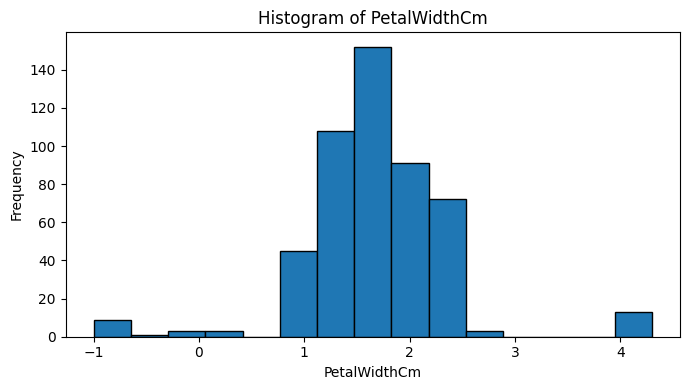

In [6]:

# 4(a) Histogram of PetalWidthCm
plt.figure(figsize=(7, 4))
plt.hist(df['PetalWidthCm'], bins=15, edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



### Observation for 4(a)

Describe the shape you see from the histogram. Typical points to mention:

- whether the values are concentrated in a narrow or wide range
- whether the distribution looks skewed or roughly balanced
- whether there seem to be multiple clusters or peaks
- whether there are possible outliers


In [7]:

# 4(b) Feature with the largest positive Pearson correlation with PetalWidthCm
candidate_features = [c for c in feature_cols if c != 'PetalWidthCm']
X_corr = df[candidate_features]
y_corr = df['PetalWidthCm']

corr_values = r_regression(X_corr, y_corr)
corr_df = pd.DataFrame({
    'feature': candidate_features,
    'pearson_corr_with_PetalWidthCm': corr_values
}).sort_values('pearson_corr_with_PetalWidthCm', ascending=False).reset_index(drop=True)

print("All correlations with PetalWidthCm:")
display(corr_df)

largest_positive = corr_df.iloc[0]
print("Feature with the largest positive correlation:")
print(largest_positive)


All correlations with PetalWidthCm:


,feature,pearson_corr_with_PetalWidthCm
0,PetalWidthCompactness,0.991670
1,PetalWidthElongation,0.991551
2,PetalWidthCurvature,0.991273
3,PetalWidthMajorAxis,0.991141
4,PetalWidthSpread,0.991095
...,...,...
64,SepalWidthMinorAxis,-0.074392
65,SepalWidthCurvature,-0.081334
66,SepalWidthCompactness,-0.088496
67,SepalGlossIndex,-0.095200


Feature with the largest positive correlation:
feature                           PetalWidthCompactness
pearson_corr_with_PetalWidthCm                  0.99167
Name: 0, dtype: object


In [8]:

# 4(c) Top 5 strongest negative correlations with PetalWidthCm
negative_corr_df = corr_df[corr_df['pearson_corr_with_PetalWidthCm'] < 0].copy()
top_negative = negative_corr_df.sort_values('pearson_corr_with_PetalWidthCm', ascending=True).head(5)

print("Top negative correlations with PetalWidthCm:")
display(top_negative)

if len(top_negative) < 5:
    print(f"Note: only {len(top_negative)} feature(s) have negative correlation in this dataset.")


Top negative correlations with PetalWidthCm:


,feature,pearson_corr_with_PetalWidthCm
68,SepalWidthMajorAxis,-0.096350
67,SepalGlossIndex,-0.095200
66,SepalWidthCompactness,-0.088496
65,SepalWidthCurvature,-0.081334
64,SepalWidthMinorAxis,-0.074392


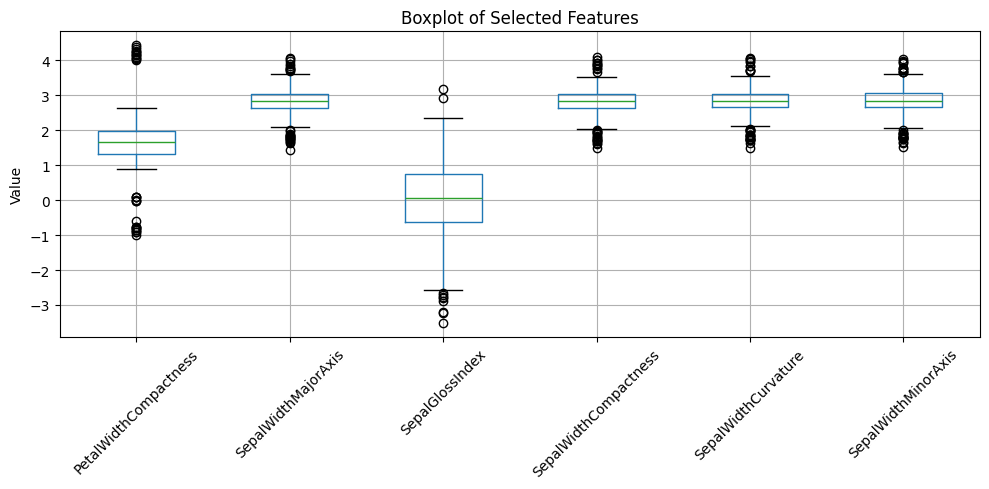

In [9]:

# 4(d) Boxplot for features found in 4(b) and 4(c)
boxplot_features = [largest_positive['feature']] + top_negative['feature'].tolist()
boxplot_features = list(dict.fromkeys(boxplot_features))  # remove duplicates while preserving order

if len(boxplot_features) > 0:
    plt.figure(figsize=(10, 5))
    df[boxplot_features].boxplot()
    plt.title('Boxplot of Selected Features')
    plt.ylabel('Value')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No features available for the requested boxplot.")


## 4. Prepare the data for model training

In [10]:

# Normalize the data to [0, 1]
df_model = df.copy()

for col in feature_cols:
    col_min = df_model[col].min()
    col_max = df_model[col].max()
    if col_max > col_min:
        df_model[col] = (df_model[col] - col_min) / (col_max - col_min)
    else:
        df_model[col] = 0.0

X = df_model[feature_cols].values.astype(float)
y = df_model['Species'].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (350, 70)
X_test : (150, 70)
y_train: (350,)
y_test : (150,)


## 5. Task 5 — Regularization

50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.6111796844177569
200. Training loss: 0.5636439627476497, Val loss:0.6019785825360591
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.588991764914238
350. Training loss: 0.5327055446405081, Val loss:0.584418742874043
400. Training loss: 0.5251667000245236, Val loss:0.58077162665673
450. Training loss: 0.5185712433977272, Val loss:0.5778662753932695
500. Training loss: 0.512749676132389, Val loss:0.5755614147648994
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860385
750. Training loss: 0.49152377948438897, Val loss:0.569

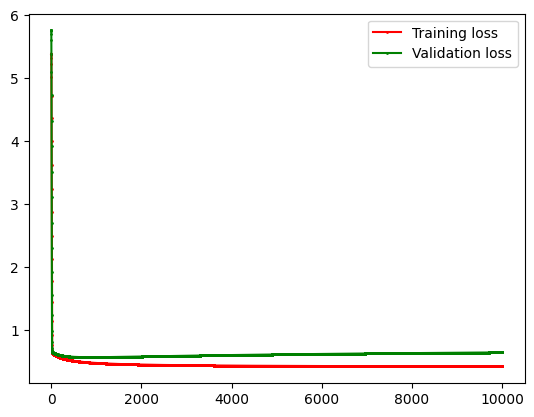

No regularization finished.
50. Training loss: 0.6183968442308057, Val loss:0.6383418749174559
100. Training loss: 0.5960218584459506, Val loss:0.6229937284988916
150. Training loss: 0.5781987940557217, Val loss:0.6111917862872271
200. Training loss: 0.563685266911725, Val loss:0.6019940821319419
250. Training loss: 0.5516390786456719, Val loss:0.5947528491389575
300. Training loss: 0.5414760921827048, Val loss:0.5890110215795246
350. Training loss: 0.5327814781753895, Val loss:0.5844381571451083
400. Training loss: 0.5252538055110114, Val loss:0.5807900103412457
450. Training loss: 0.5186692635109195, Val loss:0.5778824491950174
500. Training loss: 0.5128583316269498, Val loss:0.5755742266452544
550. Training loss: 0.5076902593666242, Val loss:0.57375533358103
600. Training loss: 0.5030625328026356, Val loss:0.5723389483402411
650. Training loss: 0.4988935840888995, Val loss:0.5712557548145529
700. Training loss: 0.4951176496280415, Val loss:0.5704498539888324
750. Training loss: 0.49

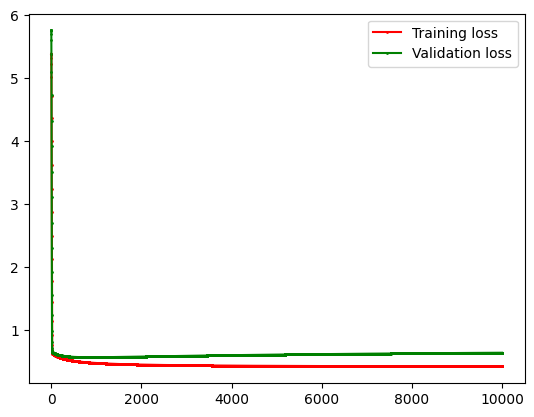

L2 (reg_lambda=0.01) finished.
50. Training loss: 0.6192229675550639, Val loss:0.6387339171797572
100. Training loss: 0.5979091328910923, Val loss:0.6238920902494233
150. Training loss: 0.5812650420168968, Val loss:0.612622557656859
200. Training loss: 0.5679827993268195, Val loss:0.6039318894908267
250. Training loss: 0.5571858255876309, Val loss:0.5971444430979668
300. Training loss: 0.5482708567526591, Val loss:0.59178857989705
350. Training loss: 0.5408117331839131, Val loss:0.5875271116871134
400. Training loss: 0.5344999386168847, Val loss:0.5841138047798571
450. Training loss: 0.5291070807888374, Val loss:0.5813654836364933
500. Training loss: 0.524460662779445, Val loss:0.5791436781671646
550. Training loss: 0.520428062804602, Val loss:0.577342251554659
600. Training loss: 0.5169056942810414, Val loss:0.5758788683267105
650. Training loss: 0.5138115085968704, Val loss:0.57468898760961
700. Training loss: 0.511079702784841, Val loss:0.5737215545999529
750. Training loss: 0.50865

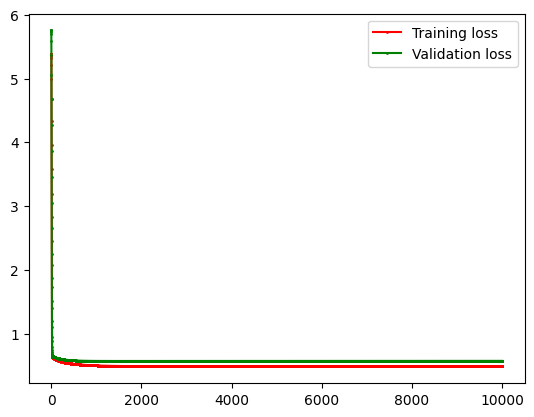

L2 (reg_lambda=1) finished.
50. Training loss: 0.6737565170340649, Val loss:0.6828695995569816
100. Training loss: 0.6747289430162428, Val loss:0.6839071965242837
150. Training loss: 0.6747483271618208, Val loss:0.6839293732638189
200. Training loss: 0.6747487102403308, Val loss:0.6839298451300981
250. Training loss: 0.674748717829201, Val loss:0.6839298552460088
300. Training loss: 0.6747487179798805, Val loss:0.6839298554645057
350. Training loss: 0.6747487179828773, Val loss:0.6839298554692588
400. Training loss: 0.674748717982937, Val loss:0.6839298554693628
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss: 0.67

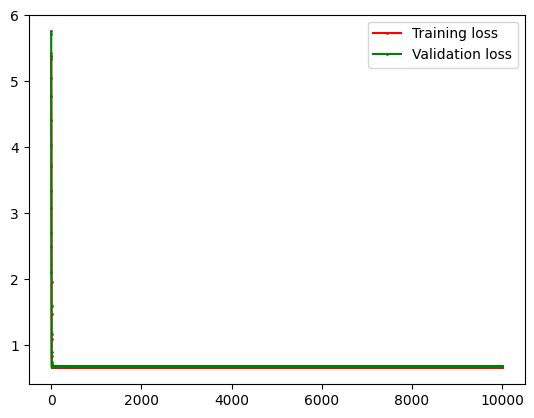

L2 (reg_lambda=100) finished.


In [11]:
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

def train_and_evaluate(reg_type='', reg_lambda=0.0, lr=0.1, n_iteration=10000):
    np.random.seed(seed)
    model = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=loss_fn,
        act_fn=act_fn,
        grad_fn=grad_fn
    )

    fit_result = model.fit(
        X_train,
        y_train,
        lr=lr,
        n_iteration=n_iteration,
        val_ratio=0.2,
        reg_type=reg_type,
        reg_lambda=reg_lambda
    )

    loss_history = None

    # Case 1: fit() returns the loss history directly
    if fit_result is not None:
        if isinstance(fit_result, (list, tuple, np.ndarray)):
            loss_history = fit_result
        elif hasattr(fit_result, '__len__') and not isinstance(fit_result, LinearModel):
            try:
                loss_history = list(fit_result)
            except:
                pass

    # Case 2: loss history is stored inside the model with a different attribute name
    if loss_history is None:
        for attr in ['losses', 'loss_list', 'loss_history', 'train_losses', 'history', 'costs']:
            if hasattr(model, attr):
                candidate = getattr(model, attr)
                if candidate is not None:
                    loss_history = candidate
                    break

    y_pred = model.predict(X_test)
    return model, y_pred, loss_history

settings = [
    ('No regularization', '', 0.0),
    ('L2 (reg_lambda=0.01)', 'l2', 0.01),
    ('L2 (reg_lambda=1)', 'l2', 1),
    ('L2 (reg_lambda=100)', 'l2', 100),
]

results = {}

for name, reg_type, reg_lambda in settings:
    model, y_pred, loss_history = train_and_evaluate(reg_type=reg_type, reg_lambda=reg_lambda)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'loss_history': loss_history
    }
    print(f"{name} finished.")



In [ ]:
# 5(a) Plot the loss curves — four figures in total
for name in results:
    loss_history = results[name]['loss_history']

    if loss_history is None:
        print(f"{name}: no loss history found in the model or fit() output.")
        print("Available attributes:", dir(results[name]['model']))
        continue

    plt.figure(figsize=(7, 4))
    plt.plot(loss_history)
    plt.title(f'Loss Curve: {name}')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.tight_layout()
    plt.show()



=== Testing result: No regularization ===
No regularization
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


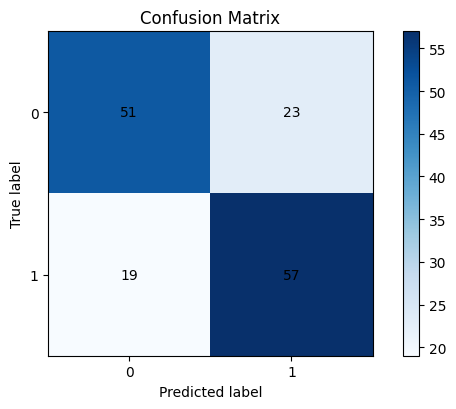


=== Testing results: L2 regularization ===

L2 (reg_lambda=0.01)
L2 (reg_lambda=0.01)
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


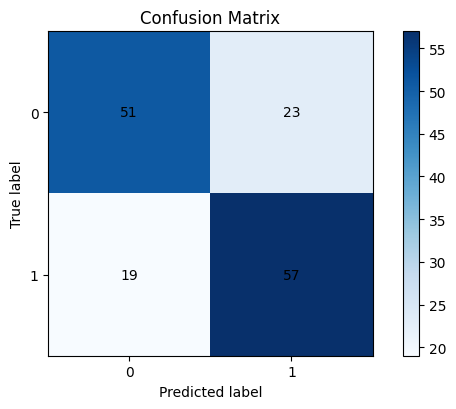


L2 (reg_lambda=1)
L2 (reg_lambda=1)
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


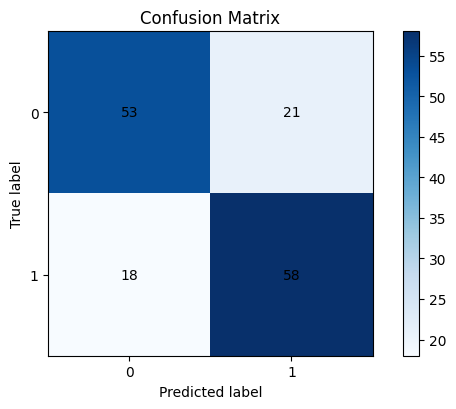


L2 (reg_lambda=100)
L2 (reg_lambda=100)
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


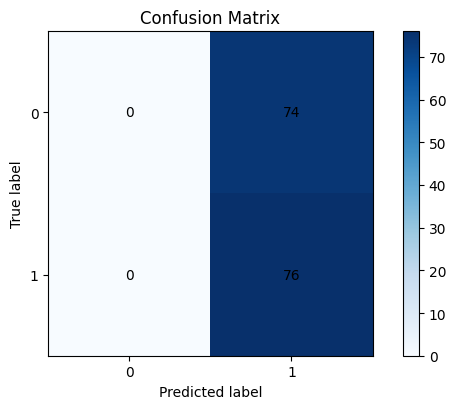

In [12]:

# 5(b) Testing results using evaluate_binary_classifier

print("=== Testing result: No regularization ===")
metrics_no_reg = evaluate_binary_classifier(
    y_test,
    results['No regularization']['y_pred'],
    title='No regularization'
)

print("\n=== Testing results: L2 regularization ===")
l2_metrics = {}
for name in ['L2 (reg_lambda=0.01)', 'L2 (reg_lambda=1)', 'L2 (reg_lambda=100)']:
    print(f"\n{name}")
    l2_metrics[name] = evaluate_binary_classifier(
        y_test,
        results[name]['y_pred'],
        title=name
    )


In [13]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metrics_only(y_true, y_pred):
    y_true = np.asarray(y_true).ravel().astype(int)
    y_pred = np.asarray(y_pred).ravel()
    if not np.array_equal(y_pred, y_pred.astype(int)):
        y_pred = (y_pred >= 0.5).astype(int)
    else:
        y_pred = y_pred.astype(int)
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
    }

metrics_table = pd.DataFrame({name: metrics_only(y_test, results[name]['y_pred']) for name in results}).T
print("Summary table:")
display(metrics_table)


Summary table:


,Accuracy,Precision,Recall,F1-score
No regularization,0.720000,0.712500,0.750000,0.730769
L2 (reg_lambda=0.01),0.720000,0.712500,0.750000,0.730769
L2 (reg_lambda=1),0.740000,0.734177,0.763158,0.748387
L2 (reg_lambda=100),0.506667,0.506667,1.000000,0.672566
